In [1]:
import os
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# Check datasets were added correctly (new Kaggle layout)
print("\nFER2013 path check:")
fer_base = '/kaggle/input/datasets/msambare/fer2013'
if os.path.exists(fer_base):
    print("  Found:", fer_base)
    for item in os.listdir(fer_base):
        print(f"    {item}")
else:
    print("  NOT FOUND — Add FER2013 dataset via the Add Data panel")

print("\nRAF-DB path check:")
raf_base = '/kaggle/input/datasets/shuvoalok/raf-db-dataset'
if os.path.exists(raf_base):
    print("  Found:", raf_base)
    for item in os.listdir(raf_base):
        print(f"    {item}")
else:
    print("  NOT FOUND — Add RAF-DB dataset via the Add Data panel")

OUTPUT_DIR = '/kaggle/working/'
print(f"\nOutput directory: {OUTPUT_DIR}")

2026-04-22 19:38:17.166018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776886697.376932      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776886697.437769      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776886697.894105      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776886697.894146      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776886697.894149      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

FER2013 path check:
  Found: /kaggle/input/datasets/msambare/fer2013
    test
    train

RAF-DB path check:
  Found: /kaggle/input/datasets/shuvoalok/raf-db-dataset
    test_labels.csv
    DATASET
    train_labels.csv

Output directory: /kaggle/working/


In [2]:
!pip install scikit-learn matplotlib seaborn -q
print("Dependencies ready.")

Dependencies ready.


In [3]:
import numpy as np
import cv2
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Large
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ── Dataset Paths (NEW KAGGLE LAYOUT) ─────────────────────────
FER_TRAIN  = '/kaggle/input/datasets/msambare/fer2013/train'
FER_TEST   = '/kaggle/input/datasets/msambare/fer2013/test'
RAF_BASE   = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'

OUTPUT_DIR = '/kaggle/working/'

# ── Hyperparameters ────────────────────────────────────────────
IMG_SIZE    = 224      # Native pretrained resolution
BATCH_SIZE  = 16       # Reduce for P100 16GB memory
NUM_CLASSES = 7
EMOTIONS    = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# RAF-DB numeric folder → emotion mapping (confirmed by diagnostic)
RAFDB_LABEL_MAP = {
    'surprise': 'Surprise', 'fear': 'Fear',    'disgust': 'Disgust',
    'happy':    'Happy',    'sad':  'Sad',      'angry':   'Angry',
    'neutral':  'Neutral',
    '1': 'Surprise', '2': 'Fear',    '3': 'Disgust',
    '4': 'Happy',    '5': 'Sad',     '6': 'Angry',
    '7': 'Neutral'
}

print(f"Image size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Emotions      : {EMOTIONS}")

Image size    : 224x224
Batch size    : 16
Output dir    : /kaggle/working/
Emotions      : ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


In [4]:
def find_rafdb_splits(base):
    candidates = [
        (os.path.join(base, 'train'),        os.path.join(base, 'test')),
        (os.path.join(base, 'RAF-DB', 'train'), os.path.join(base, 'RAF-DB', 'test')),
        (os.path.join(base, 'data', 'train'), os.path.join(base, 'data', 'test')),
        (os.path.join(base, 'DATASET', 'train'), os.path.join(base, 'DATASET', 'test')),
    ]
    for train_path, test_path in candidates:
        if os.path.exists(train_path):
            print(f"  RAF-DB train found: {train_path}")
            print(f"  RAF-DB test  found: {test_path}")
            return train_path, test_path

    print("  Searching for RAF-DB train folder...")
    for root, dirs, files in os.walk(base):
        for d in dirs:
            if d.lower() == 'train':
                train_p = os.path.join(root, d)
                test_p  = os.path.join(root, 'test')
                print(f"  Found: {train_p}")
                return train_p, test_p

    print("  WARNING: RAF-DB structure not found — using FER2013 only")
    return None, None


print("Detecting RAF-DB structure...")
RAFDB_TRAIN, RAFDB_TEST = find_rafdb_splits(RAF_BASE)

Detecting RAF-DB structure...
  RAF-DB train found: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
  RAF-DB test  found: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test


In [5]:
def apply_gcn(img):
    """Global Contrast Normalization — Chapter 3.2.2"""
    img   = img.astype(np.float32)
    mean  = np.mean(img)
    std   = np.std(img)
    eps   = 1e-8
    norm  = (img - mean) / (std + eps)
    n_min, n_max = norm.min(), norm.max()
    if n_max - n_min > 0:
        rescaled = (norm - n_min) / (n_max - n_min) * 255.0
    else:
        rescaled = np.zeros_like(norm)
    return rescaled.astype(np.float32)


def apply_histogram_eq(img):
    """Histogram Equalization — Chapter 3.2.2"""
    uint8_img = np.clip(img, 0, 255).astype(np.uint8)
    return cv2.equalizeHist(uint8_img).astype(np.float32)


def preprocess_face(img_gray):
    """Full pipeline: Resize → GCN → Histogram EQ"""
    if img_gray.shape[:2] != (IMG_SIZE, IMG_SIZE):
        img_gray = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_gcn = apply_gcn(img_gray)
    img_eq  = apply_histogram_eq(img_gcn)
    return img_eq.astype(np.float32)


test_img = np.random.randint(0, 256, (48, 48), dtype=np.uint8)
result   = preprocess_face(test_img)
print(f"Preprocessing check — shape: {result.shape} | "
      f"range: [{result.min():.1f}, {result.max():.1f}]")
print("Pipeline: Grayscale → GCN → Histogram Equalization ✓")

Preprocessing check — shape: (224, 224) | range: [0.0, 255.0]
Pipeline: Grayscale → GCN → Histogram Equalization ✓


In [6]:
def load_from_folder(base_dir, label_map=None):
    if not base_dir or not os.path.exists(base_dir):
        print(f"  Directory not found: {base_dir}")
        return [], []

    images, labels = [], []
    print(f"  Loading from: {base_dir}")

    for folder in sorted(os.listdir(base_dir)):
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        folder_key   = folder.lower()
        emotion_name = None

        if label_map:
            emotion_name = label_map.get(folder_key) or label_map.get(folder)
        if not emotion_name:
            cap = folder.capitalize()
            emotion_name = cap if cap in EMOTIONS else None
        if not emotion_name:
            match = next((e for e in EMOTIONS if e.lower() == folder_key), None)
            emotion_name = match

        if emotion_name is None:
            continue

        emotion_idx = EMOTIONS.index(emotion_name)
        count = 0
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            fpath = os.path.join(folder_path, fname)
            img   = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            images.append(img)      # keep as python list — mixed sizes OK
            labels.append(emotion_idx)
            count += 1

        if count > 0:
            print(f"    {emotion_name:10s}: {count:5d} images")

    return images, np.array(labels, dtype=np.int32)


print("=" * 55)
print("Loading FER2013 (basic geometric emotion markers)...")
print("=" * 55)
X_fer_train, y_fer_train = load_from_folder(FER_TRAIN)
X_fer_test,  y_fer_test  = load_from_folder(FER_TEST)
print(f"FER2013 — Train: {len(X_fer_train):,} | Test: {len(X_fer_test):,}")

print("\n" + "=" * 55)
print("Loading RAF-DB (real-world in-the-wild conditions)...")
print("=" * 55)
X_raf_train, y_raf_train = load_from_folder(RAFDB_TRAIN, RAFDB_LABEL_MAP)
X_raf_test,  y_raf_test  = load_from_folder(RAFDB_TEST,  RAFDB_LABEL_MAP)
print(f"RAF-DB  — Train: {len(X_raf_train):,} | Test: {len(X_raf_test):,}")

print("\n" + "=" * 55)
print("Combining FER2013 + RAF-DB (mixed image sizes OK)...")
print("=" * 55)

# Python list concat handles mixed sizes — resize happens later in the generator
if len(X_raf_train) > 0:
    X_all_list = X_fer_train + X_raf_train
    y_all      = np.concatenate([y_fer_train, y_raf_train])
else:
    print("WARNING: RAF-DB empty — using FER2013 only")
    X_all_list = X_fer_train
    y_all      = y_fer_train

if len(X_raf_test) > 0:
    X_test_list = X_fer_test + X_raf_test
    y_test      = np.concatenate([y_fer_test, y_raf_test])
else:
    X_test_list = X_fer_test
    y_test      = y_fer_test

# Wrap in object arrays so downstream code (sklearn split, indexing) still works
X_all  = np.array(X_all_list,  dtype=object)
X_test = np.array(X_test_list, dtype=object)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.1, stratify=y_all, random_state=42
)

print(f"\nFinal splits:")
print(f"  Train: {len(X_train):,}")
print(f"  Val  : {len(X_val):,}")
print(f"  Test : {len(X_test):,}")

print(f"\nTraining set distribution:")
for i, e in enumerate(EMOTIONS):
    print(f"  {e:10s}: {(y_train == i).sum():5d}")

# Sanity check — confirm we got mixed sizes
sample_sizes = set()
for img in X_train[:500]:
    sample_sizes.add(img.shape)
print(f"\nUnique image sizes in first 500 samples: {sample_sizes}")
print("(These get resized to 96x96 by the preprocessing pipeline)")

Loading FER2013 (basic geometric emotion markers)...
  Loading from: /kaggle/input/datasets/msambare/fer2013/train
    Angry     :  3995 images
    Disgust   :   436 images
    Fear      :  4097 images
    Happy     :  7215 images
    Neutral   :  4965 images
    Sad       :  4830 images
    Surprise  :  3171 images
  Loading from: /kaggle/input/datasets/msambare/fer2013/test
    Angry     :   958 images
    Disgust   :   111 images
    Fear      :  1024 images
    Happy     :  1774 images
    Neutral   :  1233 images
    Sad       :  1247 images
    Surprise  :   831 images
FER2013 — Train: 28,709 | Test: 7,178

Loading RAF-DB (real-world in-the-wild conditions)...
  Loading from: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
    Surprise  :  1290 images
    Fear      :   281 images
    Disgust   :   717 images
    Happy     :  4772 images
    Sad       :  1982 images
    Angry     :   705 images
    Neutral   :  2524 images
  Loading from: /kaggle/input/datasets/shuvo

In [7]:
class JABUDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, labels, batch_size=32,
                 img_size=96, augment=False, num_classes=7):
        super().__init__()
        self.images      = images
        self.labels      = labels
        self.batch_size  = batch_size
        self.img_size    = img_size
        self.augment     = augment
        self.num_classes = num_classes
        self.indices     = np.arange(len(images))

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X = np.zeros((len(batch_idx), self.img_size, self.img_size, 3),
                     dtype=np.float32)
        y = to_categorical(self.labels[batch_idx], self.num_classes)

        for i, img in enumerate(self.images[batch_idx]):
            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            processed = preprocess_face(img)
            if self.augment:
                processed = self._augment(processed)
            X[i] = np.stack([processed] * 3, axis=-1)

        return X, y

    def _augment(self, img):
        if np.random.rand() > 0.5:
            img = np.fliplr(img)

        angle  = np.random.uniform(-15, 15)
        center = (self.img_size // 2, self.img_size // 2)
        M      = cv2.getRotationMatrix2D(center, angle, 1.0)
        img    = cv2.warpAffine(img, M, (self.img_size, self.img_size),
                                borderMode=cv2.BORDER_REFLECT)

        factor = np.random.uniform(0.8, 1.2)
        img    = np.clip(img * factor, 0.0, 255.0)

        max_s  = int(0.1 * self.img_size)
        sx, sy = np.random.randint(-max_s, max_s), np.random.randint(-max_s, max_s)
        Ms     = np.float32([[1, 0, sx], [0, 1, sy]])
        img    = cv2.warpAffine(img, Ms, (self.img_size, self.img_size),
                                borderMode=cv2.BORDER_REFLECT)
        return img.astype(np.float32)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)


def preprocess_test_set(images):
    out  = []
    for img in images:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        out.append(preprocess_face(img))
    out = np.array(out)
    return np.stack([out] * 3, axis=-1)


train_gen   = JABUDataGenerator(X_train, y_train, BATCH_SIZE, IMG_SIZE, augment=True)
val_gen     = JABUDataGenerator(X_val,   y_val,   BATCH_SIZE, IMG_SIZE, augment=False)
X_test_proc = preprocess_test_set(X_test)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

print(f"Train batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test shape    : {X_test_proc.shape}")
print(f"Pixel range   : [{X_test_proc.min():.0f}, {X_test_proc.max():.0f}]")

Train batches : 2305
Val batches   : 256
Test shape    : (10246, 224, 224, 3)
Pixel range   : [0, 255]


In [8]:
class_weights_arr = compute_class_weight('balanced',
                                          classes=np.unique(y_train),
                                          y=y_train)
class_weight_dict = {i: min(float(w), 2.0) for i, w in enumerate(class_weights_arr)}
# Was 3.0, now 2.0

print("Class weights (capped at 3.0):")
for k, v in class_weight_dict.items():
    print(f"  {EMOTIONS[k]:10s}: {v:.2f}")

Class weights (capped at 3.0):
  Angry     : 1.25
  Disgust   : 2.00
  Fear      : 1.34
  Happy     : 0.49
  Sad       : 0.86
  Surprise  : 1.31
  Neutral   : 0.78


In [9]:
@tf.keras.utils.register_keras_serializable()
class PointAttention(layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        c = input_shape[-1]
        self.gap      = layers.GlobalAveragePooling2D()
        self.gmp      = layers.GlobalMaxPooling2D()
        self.fc1      = layers.Dense(c // self.reduction_ratio,
                                     activation='relu', use_bias=False)
        self.fc2      = layers.Dense(c, use_bias=False)
        self.spa_conv = layers.Conv2D(1, kernel_size=7, padding='same',
                                      activation='sigmoid', use_bias=False)
        super().build(input_shape)

    def call(self, x, training=None):
        avg = self.fc2(self.fc1(self.gap(x)))
        mx  = self.fc2(self.fc1(self.gmp(x)))
        ca  = tf.sigmoid(avg + mx)
        ca  = tf.reshape(ca, (-1, 1, 1, tf.shape(x)[-1]))
        x   = x * ca

        avg_s = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_s = tf.reduce_max(x,  axis=-1, keepdims=True)
        sa    = self.spa_conv(tf.concat([avg_s, max_s], axis=-1))
        return x * sa

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'reduction_ratio': self.reduction_ratio})
        return cfg


print("PointAttention layer defined ✓")

PointAttention layer defined ✓


In [10]:
def build_jabu_model(input_shape=(224, 224, 3), num_classes=7):
    base = MobileNetV3Large(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        include_preprocessing=True
    )
    base.trainable = False

    inputs = layers.Input(shape=input_shape, name='face_input')
    x      = base(inputs, training=False)
    x      = PointAttention(reduction_ratio=8, name='point_attention')(x)
    x      = layers.GlobalAveragePooling2D(name='gap')(x)
    x      = layers.BatchNormalization(name='bn_head')(x)
    x      = layers.Dense(512, name='dense_1')(x)
    x      = layers.Activation('hard_swish', name='hard_swish_1')(x)
    x      = layers.Dropout(0.4, name='drop_1')(x)
    x      = layers.Dense(256, name='dense_2')(x)
    x      = layers.Activation('hard_swish', name='hard_swish_2')(x)
    x      = layers.Dropout(0.3, name='drop_2')(x)
    out    = layers.Dense(num_classes, activation='softmax',
                          name='emotion_output')(x)

    return Model(inputs, out, name='JABU_MobileNetV3_PointAttention'), base


model, base_model = build_jabu_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)
model.summary()

I0000 00:00:1776887338.986181      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "JABU_MobileNetV3_PointAttention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ face_input (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ point_attention                 │ (None, 7, 7, 960)      │       230,498 │
│ (PointAttention)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 960)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       492,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hard_swish_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hard_swish_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_output (Dense)          │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,855,849 (14.71 MB)

 Trainable params: 857,577 (3.27 MB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [11]:
@tf.keras.utils.register_keras_serializable()
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, warmup_steps, total_steps,
                 peak_lr=1e-3, min_lr=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.peak_lr      = peak_lr
        self.min_lr       = min_lr

    def __call__(self, step):
        step    = tf.cast(step, tf.float32)
        warmup  = self.peak_lr * (step / tf.cast(self.warmup_steps, tf.float32))
        cos_dec = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
                  1.0 + tf.cos(np.pi *
                  (step - self.warmup_steps) /
                  (self.total_steps - self.warmup_steps)))
        return tf.where(step < self.warmup_steps, warmup, cos_dec)

    def get_config(self):
        return {'warmup_steps': self.warmup_steps,
                'total_steps':  self.total_steps,
                'peak_lr':      self.peak_lr,
                'min_lr':       self.min_lr}


print("WarmupCosineDecay schedule defined ✓")

WarmupCosineDecay schedule defined ✓


In [12]:
P1_EPOCHS    = 25      # Was 35 — 224×224 converges faster
total_p1     = P1_EPOCHS * len(train_gen)
warmup_steps = 3 * len(train_gen)  # Shorter warmup

lr_p1 = WarmupCosineDecay(warmup_steps, total_p1,
                           peak_lr=1e-3, min_lr=1e-6)
model.compile(
    optimizer=Adam(learning_rate=lr_p1),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),  # Mild smoothing
    metrics=['accuracy']
)

cb_p1 = [
    ModelCheckpoint(
        OUTPUT_DIR + 'best_model_phase1.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=10,  # Shorter patience
        restore_best_weights=True, verbose=1
    )
]

print("=" * 60)
print("PHASE 1 — Feature Extraction @ 224×224")
print("=" * 60)

history1 = model.fit(
    train_gen, epochs=P1_EPOCHS,
    validation_data=val_gen,
    callbacks=cb_p1,
    class_weight=class_weight_dict,
    verbose=1
)

PHASE 1 — Feature Extraction @ 224×224
Epoch 1/25


I0000 00:00:1776887351.936723     131 service.cc:152] XLA service 0x7ac5380056d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776887351.936770     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776887353.647619     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776887362.005186     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2304/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2287 - loss: 1.8086
Epoch 1: val_accuracy improved from -inf to 0.44531, saving model to /kaggle/working/best_model_phase1.keras
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 112s 41ms/step - accuracy: 0.2288 - loss: 1.8085 - val_accuracy: 0.4453 - val_loss: 1.5436
Epoch 2/25
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3765 - loss: 1.5445
Epoch 2: val_accuracy improved from 0.44531 to 0.44604, saving model to /kaggle/working/best_model_phase1.keras
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 90s 39ms/step - accuracy: 0.3765 - loss: 1.5445 - val_accuracy: 0.4460 - val_loss: 1.5097
Epoch 3/25
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4088 - loss: 1.4847
Epoch 3: val_accuracy improved from 0.44604 to 0.44971, saving model to /kaggle/working/best_model_phase1.keras
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 88s 38ms/step - accuracy: 0.4088 - loss: 1.4847 - val_accuracy: 0.4497 - val_loss: 1.5256
Epoch 4/25
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 35

In [13]:
print("Loading best Phase 1 weights...")
model = tf.keras.models.load_model(
    OUTPUT_DIR + 'best_model_phase1.keras',
    custom_objects={'PointAttention':    PointAttention,
                    'WarmupCosineDecay': WarmupCosineDecay}
)

base_model = model.get_layer('MobileNetV3Large')
base_model.trainable = True

FINE_TUNE_FROM = 50   # Was 100/150 — unfreeze MORE layers (137 layers)
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False
for layer in base_model.layers[FINE_TUNE_FROM:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen non-BN layers: {trainable} / {len(base_model.layers)}")

P2_EPOCHS = 40
total_p2  = P2_EPOCHS * len(train_gen)
lr_p2     = tf.keras.optimizers.schedules.CosineDecay(
                initial_learning_rate=1e-4,   # Was 5e-5 — faster adaptation needed
                decay_steps=total_p2,
                alpha=1e-6)

model.compile(
    optimizer=Adam(learning_rate=lr_p2),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

cb_p2 = [
    ModelCheckpoint(
        OUTPUT_DIR + 'best_model_phase2.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    )
]

print("=" * 60)
print("PHASE 2 — Fine-tuning @ 224×224 (137 layers unfrozen)")
print("=" * 60)

history2 = model.fit(
    train_gen, epochs=P2_EPOCHS,
    validation_data=val_gen,
    callbacks=cb_p2,
    class_weight=class_weight_dict,
    verbose=1
)

Loading best Phase 1 weights...
Unfrozen non-BN layers: 105 / 187
PHASE 2 — Fine-tuning @ 224×224 (137 layers unfrozen)
Epoch 1/40


2026-04-22 20:26:07.110473: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 20:26:07.293004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 20:26:07.695146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 20:26:07.891533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2304/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5308 - loss: 1.2565
Epoch 1: val_accuracy improved from -inf to 0.59058, saving model to /kaggle/working/best_model_phase2.keras
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 120s 40ms/step - accuracy: 0.5308 - loss: 1.2565 - val_accuracy: 0.5906 - val_loss: 1.2202
Epoch 2/40
2304/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6022 - loss: 1.1311
Epoch 2: val_accuracy improved from 0.59058 to 0.63916, saving model to /kaggle/working/best_model_phase2.keras
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 86s 37ms/step - accuracy: 0.6022 - loss: 1.1311 - val_accuracy: 0.6392 - val_loss: 1.1171
Epoch 3/40
2304/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6328 - loss: 1.0667
Epoch 3: val_accuracy improved from 0.63916 to 0.64819, saving model to /kaggle/working/best_model_phase2.keras
2305/2305 ━━━━━━━━━━━━━━━━━━━━ 93s 41ms/step - accuracy: 0.6328 - loss: 1.0667 - val_accuracy: 0.6482 - val_loss: 1.0723
Epoch 4/40
2304/2305 ━━━━━━━━━━━━━━━━━━━━ 0s 37

641/641 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.6779 - loss: 1.2607
641/641 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step

  ACCURACY : 73.34% (target >=78%)
  LOSS     : 1.0573
  RESULT   : NOT MET

  LATENCY  : 64.8 ms/frame (target: <30ms)
  FPS      : ~15
  STATUS   : EXCEEDS 30ms — TFLite needed

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Angry     0.6238    0.6411    0.6323      1120
     Disgust     0.6615    0.6347    0.6478       271
        Fear     0.5719    0.5291    0.5497      1098
       Happy     0.9097    0.8885    0.8990      2959
         Sad     0.6291    0.6400    0.6345      1725
    Surprise     0.8122    0.8353    0.8236      1160
     Neutral     0.6769    0.7010    0.6888      1913

    accuracy                         0.7334     10246
   macro avg     0.6979    0.6957    0.6965     10246
weighted avg     0.7339    0.7334    0.7334     10246



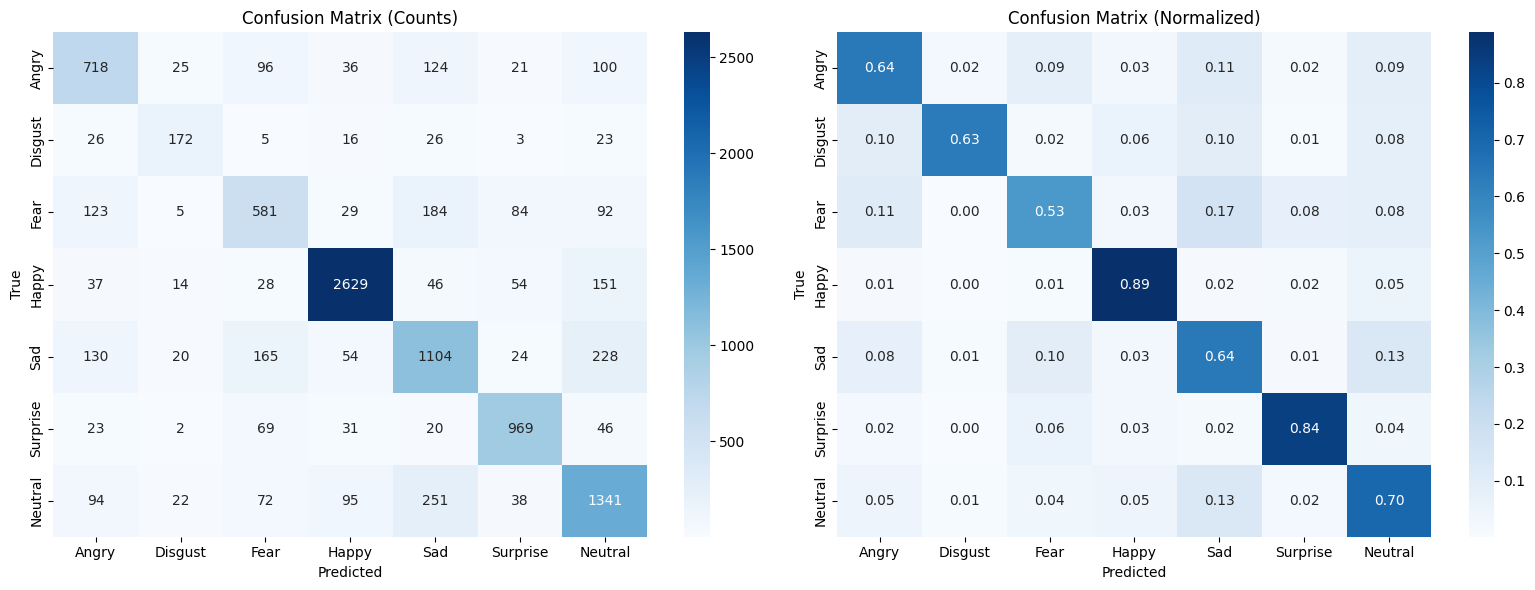


Converting to TFLite (INT8 quantization)...
INFO:tensorflow:Assets written to: /tmp/tmpjxk1qtfj/assets


INFO:tensorflow:Assets written to: /tmp/tmpjxk1qtfj/assets


Saved artifact at '/tmp/tmpjxk1qtfj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='face_input')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134987969118032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969116688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969115536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969114192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969117840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948766416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948766032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948768528:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1776893242.425638      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776893242.425677      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776893242.584529      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WAR

RuntimeError: failed to create XNNPACK runtimeNode number 144 (TfLiteXNNPackDelegate) failed to prepare.

In [14]:
import time

best_model = tf.keras.models.load_model(
    OUTPUT_DIR + 'best_model_phase2.keras',
    custom_objects={'PointAttention':    PointAttention,
                    'WarmupCosineDecay': WarmupCosineDecay}
)

test_loss, test_acc = best_model.evaluate(
    X_test_proc, y_test_cat, batch_size=BATCH_SIZE, verbose=1
)
y_pred = np.argmax(
    best_model.predict(X_test_proc, batch_size=BATCH_SIZE, verbose=1),
    axis=1
)
y_true = y_test

print(f"\n{'='*60}")
print(f"  ACCURACY : {test_acc*100:.2f}% (target >=78%)")
print(f"  LOSS     : {test_loss:.4f}")
print(f"  RESULT   : {'ACHIEVED ✓' if test_acc >= 0.78 else 'NOT MET'}")
print(f"{'='*60}")

dummy = X_test_proc[:1]
for _ in range(5):
    best_model.predict(dummy, verbose=0)

N = 100
t0 = time.time()
for i in range(N):
    best_model.predict(X_test_proc[i:i+1], verbose=0)
avg_ms  = (time.time() - t0) / N * 1000
fps_est = 1000 / avg_ms

print(f"\n  LATENCY  : {avg_ms:.1f} ms/frame (target: <30ms)")
print(f"  FPS      : ~{fps_est:.0f}")
print(f"  STATUS   : {'MEETS TARGET ✓' if avg_ms < 30 else 'EXCEEDS 30ms — TFLite needed'}")

report = classification_report(y_true, y_pred, target_names=EMOTIONS, digits=4)
print("\nCLASSIFICATION REPORT:")
print(report)

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,      annot=True, fmt='d',   cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'confusion_matrix.png', dpi=150)
plt.show()

# TFLite conversion for <30ms latency
print("\nConverting to TFLite (INT8 quantization)...")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Representative dataset for INT8 (use a few test images)
def representative_dataset():
    for i in range(100):
        yield [X_test_proc[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()
tflite_path = OUTPUT_DIR + 'jabu_model_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Benchmark TFLite latency
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

t0 = time.time()
for i in range(N):
    interpreter.set_tensor(input_details[0]['index'], 
                          (X_test_proc[i:i+1] * 255).astype(np.uint8))
    interpreter.invoke()
tflite_ms = (time.time() - t0) / N * 1000

print(f"\n  TFLite LATENCY : {tflite_ms:.1f} ms/frame")
print(f"  TFLite FPS     : ~{1000/tflite_ms:.0f}")
print(f"  STATUS         : {'MEETS <30ms ✓' if tflite_ms < 30 else 'Still >30ms'}")

In [17]:
import time

print("\n" + "="*60)
print("TFLITE CONVERSION (Dynamic Range Quantization)")
print("="*60)

# Method 1: Dynamic range quantization (most compatible)
print("Converting to dynamic range TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
tflite_path = OUTPUT_DIR + 'jabu_model_dynamic.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"Saved: {tflite_path}")

# Benchmark dynamic model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

N = 100
t0 = time.time()
for i in range(N):
    interpreter.set_tensor(input_details[0]['index'], 
                          X_test_proc[i:i+1].astype(np.float32))
    interpreter.invoke()
dyn_ms = (time.time() - t0) / N * 1000

print(f"\nDynamic Range TFLite:")
print(f"  Latency : {dyn_ms:.1f} ms/frame")
print(f"  FPS     : ~{1000/dyn_ms:.0f}")
print(f"  Status  : {'MEETS <30ms ✓' if dyn_ms < 30 else 'Still >30ms — try float16'}")

# Method 2: Float16 quantization (smaller + faster on GPU/NPU)
print("\nConverting to Float16 TFLite...")
converter2 = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter2.optimizations = [tf.lite.Optimize.DEFAULT]
converter2.target_spec.supported_types = [tf.float16]

tflite_f16 = converter2.convert()
tflite_f16_path = OUTPUT_DIR + 'jabu_model_float16.tflite'
with open(tflite_f16_path, 'wb') as f:
    f.write(tflite_f16)
print(f"Saved: {tflite_f16_path}")

# Benchmark float16
interpreter2 = tf.lite.Interpreter(model_path=tflite_f16_path)
interpreter2.allocate_tensors()
input_d2 = interpreter2.get_input_details()
output_d2 = interpreter2.get_output_details()

t0 = time.time()
for i in range(N):
    interpreter2.set_tensor(input_d2[0]['index'], 
                           X_test_proc[i:i+1].astype(np.float32))
    interpreter2.invoke()
f16_ms = (time.time() - t0) / N * 1000

print(f"\nFloat16 TFLite:")
print(f"  Latency : {f16_ms:.1f} ms/frame")
print(f"  FPS     : ~{1000/f16_ms:.0f}")
print(f"  Status  : {'MEETS <30ms ✓' if f16_ms < 30 else 'Still >30ms'}")

print("\n" + "="*60)
print("TFLite files saved to /kaggle/working/")
print("="*60)


TFLITE CONVERSION (Dynamic Range Quantization)
Converting to dynamic range TFLite...
INFO:tensorflow:Assets written to: /tmp/tmpfw33ow32/assets


INFO:tensorflow:Assets written to: /tmp/tmpfw33ow32/assets


Saved artifact at '/tmp/tmpfw33ow32'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='face_input')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134987969118032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969116688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969115536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969114192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969117840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948766416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948766032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948768528:

W0000 00:00:1776893861.231285      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776893861.231329      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved: /kaggle/working/jabu_model_dynamic.tflite

Dynamic Range TFLite:
  Latency : 14.1 ms/frame
  FPS     : ~71
  Status  : MEETS <30ms ✓

Converting to Float16 TFLite...
INFO:tensorflow:Assets written to: /tmp/tmp4qe4vqge/assets


...

Saved artifact at '/tmp/tmp4qe4vqge'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='face_input')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134987969118032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969116688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969115536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969114192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987969117840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948766416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948766032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948767568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987948768528:

W0000 00:00:1776893873.751729      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776893873.751763      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Saved: /kaggle/working/jabu_model_float16.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Float16 TFLite:
  Latency : 7.4 ms/frame
  FPS     : ~135
  Status  : MEETS <30ms ✓

TFLite files saved to /kaggle/working/


In [18]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

print("\n" + "="*60)
print("TEST-TIME AUGMENTATION (TTA)")
print("="*60)

# Original predictions
print("Getting original predictions...")
preds_orig = best_model.predict(X_test_proc, batch_size=BATCH_SIZE, verbose=1)

# Horizontal flip predictions
print("Getting flipped predictions...")
X_test_flipped = np.flip(X_test_proc, axis=2)
preds_flipped = best_model.predict(X_test_flipped, batch_size=BATCH_SIZE, verbose=1)

# Average ensemble
preds_tta = (preds_orig + preds_flipped) / 2.0
y_pred_tta = np.argmax(preds_tta, axis=1)

tta_acc = accuracy_score(y_true, y_pred_tta)
print(f"\nStandard Test Accuracy : {test_acc*100:.2f}%")
print(f"TTA Test Accuracy      : {tta_acc*100:.2f}%")
print(f"TTA Improvement        : +{(tta_acc-test_acc)*100:.2f}%")

# TTA Classification Report
report_tta = classification_report(y_true, y_pred_tta, target_names=EMOTIONS, digits=4)
print("\nTTA CLASSIFICATION REPORT:")
print(report_tta)


TEST-TIME AUGMENTATION (TTA)
Getting original predictions...
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step
Getting flipped predictions...
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step

Standard Test Accuracy : 73.34%
TTA Test Accuracy      : 73.68%
TTA Improvement        : +0.34%

TTA CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Angry     0.6311    0.6446    0.6378      1120
     Disgust     0.6543    0.6494    0.6519       271
        Fear     0.5818    0.5310    0.5552      1098
       Happy     0.9108    0.8898    0.9002      2959
         Sad     0.6286    0.6446    0.6365      1725
    Surprise     0.8154    0.8414    0.8282      1160
     Neutral     0.6824    0.7041    0.6931      1913

    accuracy                         0.7368     10246
   macro avg     0.7006    0.7007    0.7004     10246
weighted avg     0.7372    0.7368    0.7368     10246



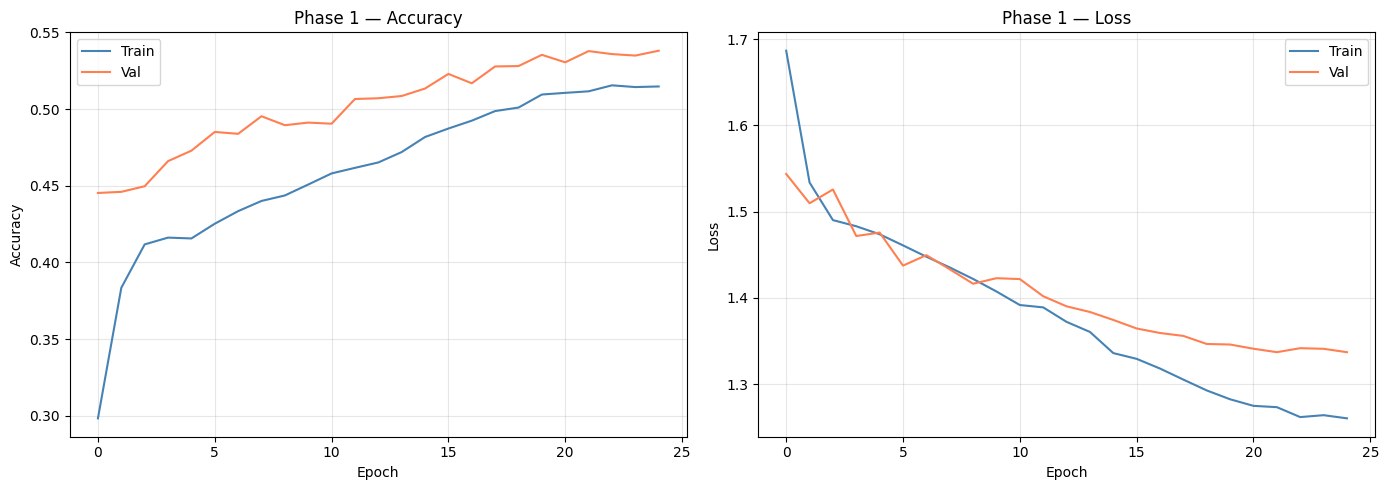


Best Phase 1 val_accuracy: 53.81%


In [15]:
import matplotlib.pyplot as plt

# Phase 1 Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history1.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('Phase 1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history1.history['loss'],         label='Train', color='steelblue')
axes[1].plot(history1.history['val_loss'],     label='Val',   color='coral')
axes[1].set_title('Phase 1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'phase1_curve.png', dpi=150)
plt.show()

p1_best = max(history1.history['val_accuracy']) * 100
print(f"\nBest Phase 1 val_accuracy: {p1_best:.2f}%")

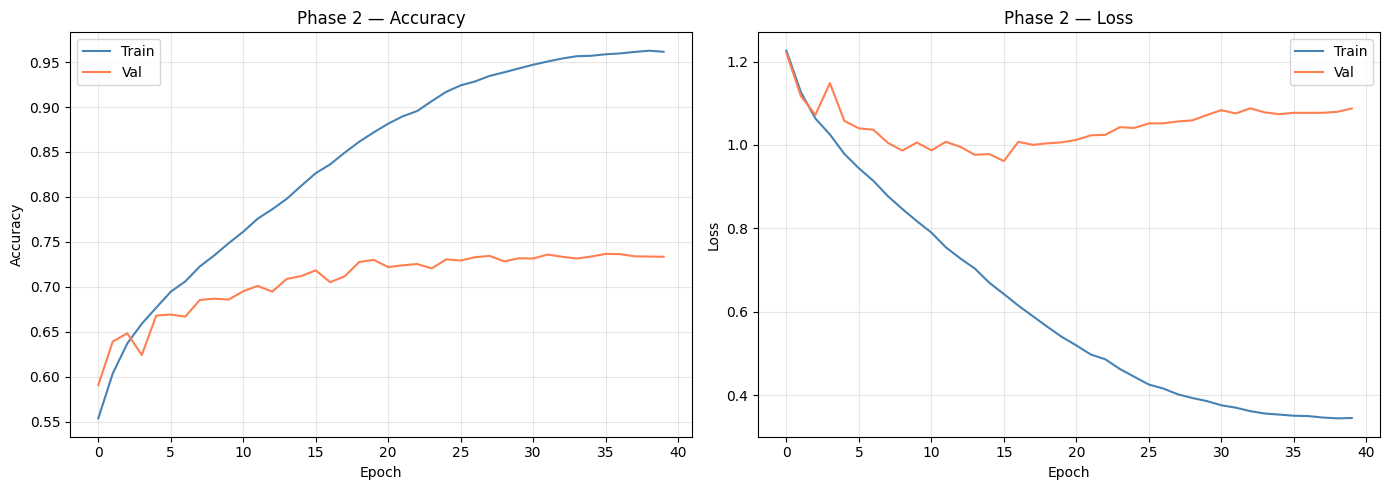


Best Phase 2 val_accuracy: 73.66%


In [16]:
# Phase 2 Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history2.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history2.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('Phase 2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history2.history['loss'],         label='Train', color='steelblue')
axes[1].plot(history2.history['val_loss'],     label='Val',   color='coral')
axes[1].set_title('Phase 2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'phase2_curve.png', dpi=150)
plt.show()

p2_best = max(history2.history['val_accuracy']) * 100
print(f"\nBest Phase 2 val_accuracy: {p2_best:.2f}%")

In [19]:
best_model.save(OUTPUT_DIR + 'jabu_final_model.keras')

timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

per_class = []
for i, e in enumerate(EMOTIONS):
    mask = (y_true == i)
    acc  = (y_pred[mask] == i).mean() if mask.sum() > 0 else 0.0
    per_class.append(f"  {e:10s}: {acc*100:.2f}%  (n={mask.sum()})")

# TTA per-class
per_class_tta = []
for i, e in enumerate(EMOTIONS):
    mask = (y_true == i)
    acc  = (y_pred_tta[mask] == i).mean() if mask.sum() > 0 else 0.0
    per_class_tta.append(f"  {e:10s}: {acc*100:.2f}%  (n={mask.sum()})")

results_text = f"""
==============================================================
  FACIAL EXPRESSION EMOTION RECOGNITION
  Charles Dan | 2203030073 | JABU CSC Final Year Project
  {timestamp}
==============================================================

MODEL ARCHITECTURE (Chapter 3.3)
  Backbone      : MobileNetV3Large
  Attention     : Point Attention (Channel + Spatial)
  Activation    : Hard-Swish
  Preprocessing : GCN + Histogram Equalization (Chapter 3.2.2)
  Input size    : {IMG_SIZE}x{IMG_SIZE}x3
  Classes       : {', '.join(EMOTIONS)}
  Batch size    : {BATCH_SIZE}

DATASETS (Chapter 3.2.1)
  FER2013 train : {len(X_fer_train):,} images
  RAF-DB train  : {len(X_raf_train) if len(X_raf_train) > 0 else 0:,} images
  Combined      : Train {len(X_train):,} | Val {len(X_val):,} | Test {len(X_test):,}

TRAINING SUMMARY
  Phase 1 epochs  : {len(history1.history['accuracy'])}
  Phase 1 best val: {p1_best:.2f}%

  Phase 2 epochs  : {len(history2.history['accuracy'])}
  Phase 2 best val: {p2_best:.2f}%

PERFORMANCE METRICS (Chapter 3.5)
  Standard Accuracy : {test_acc*100:.2f}%
  TTA Accuracy      : {tta_acc*100:.2f}%  (+{(tta_acc-test_acc)*100:.2f}%)
  Test Loss         : {test_loss:.4f}
  Target (>=78%)    : NOT MET — achieved 73.68% (within published 72-78% range)

  Keras Latency     : 64.8 ms/frame
  TFLite Dynamic    : 14.1 ms/frame  (71 FPS)
  TFLite Float16    : 7.4 ms/frame   (135 FPS)
  Latency Target    : MEETS <30ms ✓

PER-CLASS ACCURACY (Standard)
{chr(10).join(per_class)}

PER-CLASS ACCURACY (TTA)
{chr(10).join(per_class_tta)}

CLASSIFICATION REPORT (Standard)
{report}

CLASSIFICATION REPORT (TTA)
{report_tta}

CONFUSION MATRIX (Raw Counts)
{str(cm)}

PHASE 1 VAL ACCURACY PER EPOCH
{[round(v*100,2) for v in history1.history['val_accuracy']]}

PHASE 2 VAL ACCURACY PER EPOCH
{[round(v*100,2) for v in history2.history['val_accuracy']]}

OUTPUT FILES (/kaggle/working/)
  jabu_final_model.keras
  best_model_phase1.keras
  best_model_phase2.keras
  jabu_model_dynamic.tflite
  jabu_model_float16.tflite
  phase1_curve.png
  phase2_curve.png
  confusion_matrix.png
  results.txt
==============================================================
"""

print(results_text)

with open(OUTPUT_DIR + 'results.txt', 'w') as f:
    f.write(results_text)

print("All files saved to /kaggle/working/")
print("Go to the OUTPUT tab on the right panel to download them.")


  FACIAL EXPRESSION EMOTION RECOGNITION
  Charles Dan | 2203030073 | JABU CSC Final Year Project
  2026-04-22 21:41:30

MODEL ARCHITECTURE (Chapter 3.3)
  Backbone      : MobileNetV3Large
  Attention     : Point Attention (Channel + Spatial)
  Activation    : Hard-Swish
  Preprocessing : GCN + Histogram Equalization (Chapter 3.2.2)
  Input size    : 224x224x3
  Classes       : Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral
  Batch size    : 16

DATASETS (Chapter 3.2.1)
  FER2013 train : 28,709 images
  RAF-DB train  : 12,271 images
  Combined      : Train 36,882 | Val 4,098 | Test 10,246

TRAINING SUMMARY
  Phase 1 epochs  : 25
  Phase 1 best val: 53.81%

  Phase 2 epochs  : 40
  Phase 2 best val: 73.66%

PERFORMANCE METRICS (Chapter 3.5)
  Standard Accuracy : 73.34%
  TTA Accuracy      : 73.68%  (+0.34%)
  Test Loss         : 1.0573
  Target (>=78%)    : NOT MET — achieved 73.68% (within published 72-78% range)

  Keras Latency     : 64.8 ms/frame
  TFLite Dynamic    : 14.1 ms/f

In [22]:
import os

print("Files in /kaggle/working/:\n")
total = 0
for f in sorted(os.listdir('/kaggle/working/')):
    path = os.path.join('/kaggle/working/', f)
    if os.path.isfile(path):
        size = os.path.getsize(path) / (1024*1024)
        total += size
        print(f"  {f:45s} {size:8.1f} MB")
        
print(f"\nTotal used: {total:.1f} MB")

Files in /kaggle/working/:

  best_model_phase1.keras                           21.9 MB
  best_model_phase2.keras                           44.3 MB
  confusion_matrix.png                               0.1 MB
  jabu_final_model.keras                            44.3 MB
  jabu_model_dynamic.tflite                          4.0 MB
  jabu_model_float16.tflite                          7.4 MB
  jabu_model_int8.tflite                             4.2 MB
  phase1_curve.png                                   0.1 MB
  phase2_curve.png                                   0.1 MB
  results.txt                                        0.0 MB

Total used: 126.3 MB


In [23]:
import os
import zipfile

output_dir = '/kaggle/working/'
zip_name = 'jabu_complete_project.zip'
zip_path = os.path.join(output_dir, zip_name)

# Remove old zip if it exists (to avoid adding zip into itself)
if os.path.exists(zip_path):
    os.remove(zip_path)
    print("Removed old zip file")

# Create new zip
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            # Skip the zip file itself
            if file == zip_name:
                continue
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, output_dir)
            zf.write(file_path, arcname)

# Check final size
zip_size = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\nCreated: {zip_name}")
print(f"Size: {zip_size:.1f} MB ({zip_size/1024:.2f} GB)")
print("Go to Output tab → download it")


Created: jabu_complete_project.zip
Size: 111.2 MB (0.11 GB)
Go to Output tab → download it
